# Chapter 12 - Cross-Validation and Model Evaluation Techniques
## Reliable Performance Estimation in Machine Learning

## Objective
Learn how to evaluate models fairly using train/test split, k-fold cross-validation, and multiple metrics.

## Theory Introduction
A single train-test split can give unstable estimates. Cross-validation repeatedly splits data into folds to provide a more reliable estimate of model performance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score, validation_curve, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
plt.style.use('ggplot')

In [2]:
data=load_wine()
X,y=data.data,data.target
pipe=Pipeline([('scaler',StandardScaler()),('model',SVC(kernel='rbf',C=1.0))])

## Holdout Evaluation

In [3]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
pipe.fit(X_train,y_train)
print('Test Accuracy:', round(pipe.score(X_test,y_test),4))

Test Accuracy: 0.9778


## K-Fold Cross Validation

In [4]:
scores=cross_val_score(pipe,X,y,cv=5)
print(scores)
print('Mean CV Accuracy:', round(scores.mean(),4))

[1.         0.97222222 0.94444444 1.         1.        ]
Mean CV Accuracy: 0.9833


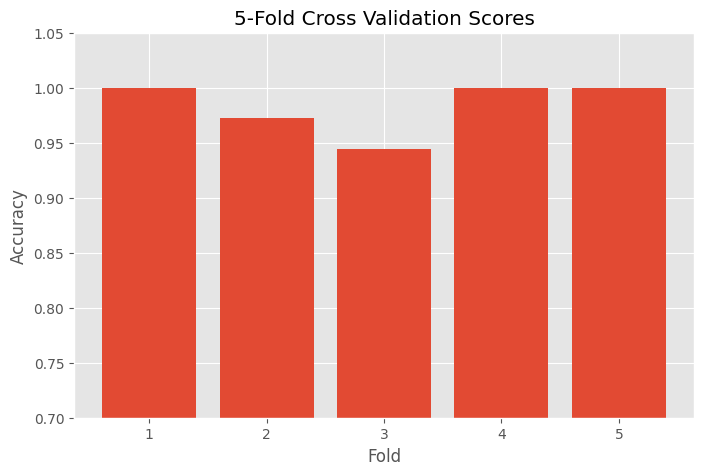

In [5]:
plt.figure(figsize=(8,5))
plt.bar(range(1,6),scores)
plt.ylim(0.7,1.05)
plt.title('5-Fold Cross Validation Scores')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.show()

**Description:** Scores across folds show stability of model performance.

## Validation Curve for C Parameter

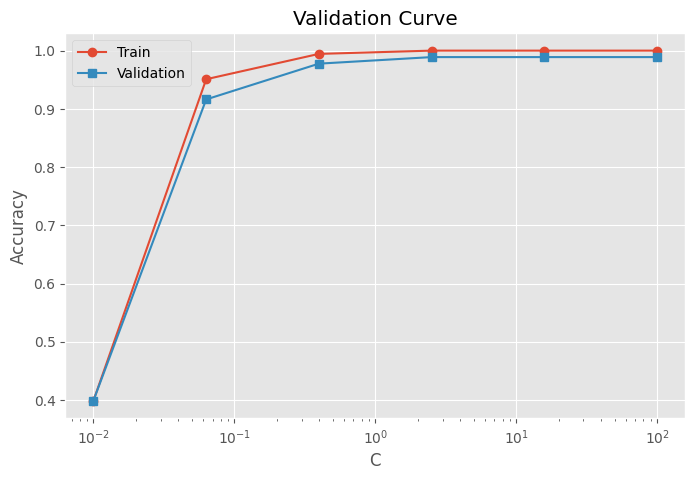

In [6]:
param_range=np.logspace(-2,2,6)
train_scores,test_scores=validation_curve(pipe,X,y,param_name='model__C',param_range=param_range,cv=5)
plt.figure(figsize=(8,5))
plt.semilogx(param_range,train_scores.mean(axis=1),marker='o',label='Train')
plt.semilogx(param_range,test_scores.mean(axis=1),marker='s',label='Validation')
plt.title('Validation Curve')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Description:** Helps identify underfitting or overfitting across parameter values.

## Learning Curve

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last

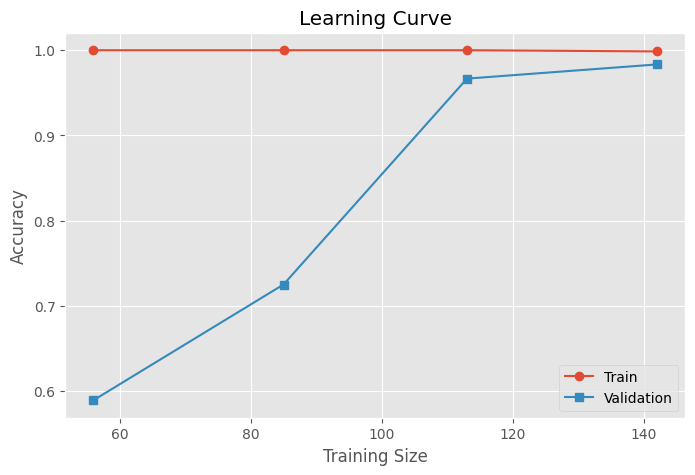

In [7]:
sizes,train_l,test_l=learning_curve(pipe,X,y,cv=5,train_sizes=np.linspace(0.2,1.0,5))
plt.figure(figsize=(8,5))
plt.plot(sizes,train_l.mean(axis=1),marker='o',label='Train')
plt.plot(sizes,test_l.mean(axis=1),marker='s',label='Validation')
plt.title('Learning Curve')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Description:** Shows whether more training data may improve performance.

## Important Concepts
- Data leakage
- K-Fold CV
- Bias vs variance in estimates
- Hyperparameter tuning
- Learning curves

## Summary
Cross-validation provides a more trustworthy estimate than a single split. Validation and learning curves help diagnose model behavior.